# Model Explainability with SHAP (Task 3)

## Objective
This notebook focuses on explaining the predictions of our best classification model (XGBoost) for the E-commerce fraud dataset. We will:
1. Extract built-in feature importances from XGBoost.
2. Generate global explainability plots using SHAP (Beeswarm/Summary Plot).
3. Inspect individual predictions for True Positives, False Positives, and False Negatives using SHAP Force Plots.
4. Synthesize findings into concrete, actionable business recommendations for Adey Innovations Inc.


In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib to inline and use a high-quality style
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Libraries loaded successfully!")


Libraries loaded successfully!


## 1. Load Preprocessed Data and Model
We load the trained XGBoost model and the preprocessed test set splits.

In [2]:
model_path = '../models/xgb_fraud_data.pkl'
x_test_path = '../data/processed/fraud_X_test.csv'
y_test_path = '../data/processed/fraud_y_test.csv'

model = joblib.load(model_path)
X_test = pd.read_csv(x_test_path)
y_test = pd.read_csv(y_test_path).values.ravel()

print(f"XGBoost model loaded successfully: {type(model)}")
print(f"Test features shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")


XGBoost model loaded successfully: <class 'xgboost.sklearn.XGBClassifier'>
Test features shape: (30223, 196)
Test labels shape: (30223,)


## 2. Make Predictions and Segment Instances
We make predictions on the test set and calculate evaluation metrics. We also isolate specific cases for individual explanations:
- **True Positive (TP)**: Actual Fraud (1) predicted as Fraud (1)
- **False Positive (FP)**: Legitimate (0) predicted as Fraud (1)
- **False Negative (FN)**: Actual Fraud (1) predicted as Legitimate (0)

In [3]:
probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

tp_idx = np.where((y_test == 1) & (preds == 1))[0]
fp_idx = np.where((y_test == 0) & (preds == 1))[0]
fn_idx = np.where((y_test == 1) & (preds == 0))[0]
tn_idx = np.where((y_test == 0) & (preds == 0))[0]

print(f"Total Test Instances:  {len(y_test):,}")
print(f"True Positives (TP):   {len(tp_idx):,} (Index {tp_idx[0]} chosen for explanation)")
print(f"False Positives (FP):  {len(fp_idx):,} (Index {fp_idx[0]} chosen for explanation)")
print(f"False Negatives (FN):  {len(fn_idx):,} (Index {fn_idx[0]} chosen for explanation)")
print(f"True Negatives (TN):   {len(tn_idx):,}")


Total Test Instances:  30,223
True Positives (TP):   1,533 (Index 2 chosen for explanation)
False Positives (FP):  51 (Index 344 chosen for explanation)
False Negatives (FN):  1,297 (Index 25 chosen for explanation)
True Negatives (TN):   27,342


## 3. Built-in Feature Importance
We plot the built-in feature importances from our trained XGBoost ensemble model. This acts as our baseline for global feature importance.

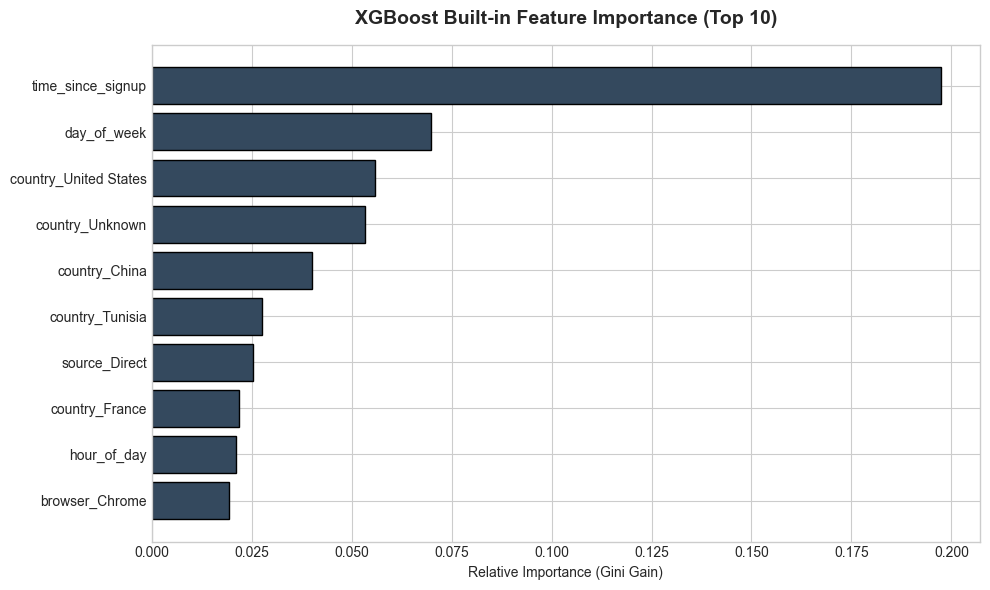

In [4]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Select top 10
top_10_idx = indices[:10]
top_10_features = X_test.columns[top_10_idx]
top_10_importances = importances[top_10_idx]

plt.figure(figsize=(10, 6))
plt.barh(top_10_features[::-1], top_10_importances[::-1], color='#34495e', edgecolor='black')
plt.title("XGBoost Built-in Feature Importance (Top 10)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Relative Importance (Gini Gain)")
plt.tight_layout()
plt.savefig('../data/processed/builtin_feature_importance.png', dpi=150)
plt.show()


## 4. SHAP Global Explainability
We initialize a SHAP `TreeExplainer` on the trained XGBoost model and compute SHAP values for a representative sample of 1,000 instances from the test set. This shows not just *which* features are important, but *how* their values influence the probability of fraud.

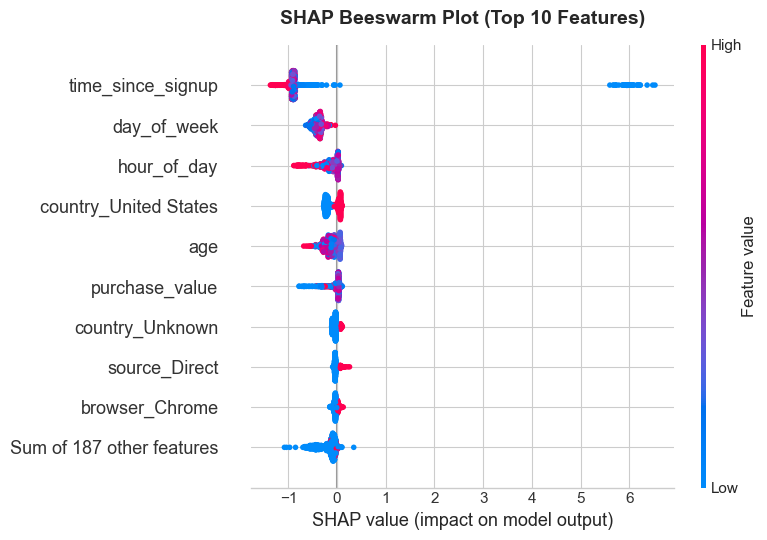

In [5]:
explainer = shap.TreeExplainer(model)
X_sub = X_test.iloc[:1000]
shap_values_sub = explainer(X_sub)

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_sub, max_display=10, show=False)
plt.title("SHAP Beeswarm Plot (Top 10 Features)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/processed/shap_summary_plot.png', dpi=150)
plt.show()


## 5. SHAP Individual Explanations (Force Plots)
We visualize force plots for three individual transactions: a True Positive, a False Positive, and a False Negative. These plots show which features pushed the model prediction away from the base value (the average prediction across the dataset).

### 5.1 True Positive (TP) — Correctly Identified Fraud
This is an actual fraud case that the model successfully flagged.

<Figure size 1200x400 with 0 Axes>

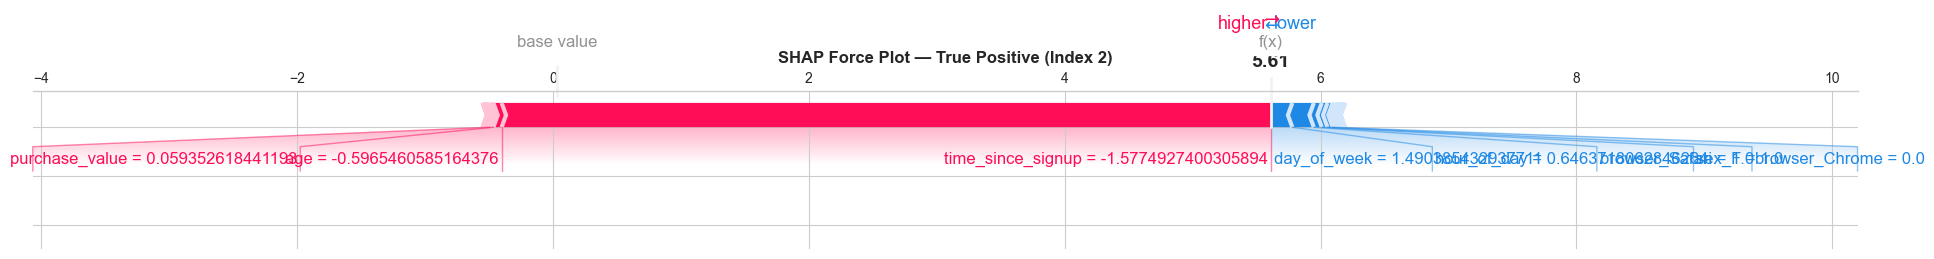

In [6]:
tp_sample_idx = tp_idx[0]
shap_vals_tp = explainer(X_test.iloc[[tp_sample_idx]])
base_val = explainer.expected_value
if isinstance(base_val, np.ndarray):
    base_val = base_val[0]

plt.figure(figsize=(12, 4))
shap.force_plot(
    base_val, 
    shap_vals_tp[0].values, 
    X_test.iloc[tp_sample_idx], 
    matplotlib=True, 
    show=False
)
plt.title(f"SHAP Force Plot — True Positive (Index {tp_sample_idx})", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/processed/shap_force_true_positive.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 False Positive (FP) — Legitimate Transaction Flagged as Fraud
This is a legitimate transaction that the model flagged as fraud. Explaining these helps us reduce user friction by identifying features causing false alarms.

<Figure size 1200x400 with 0 Axes>

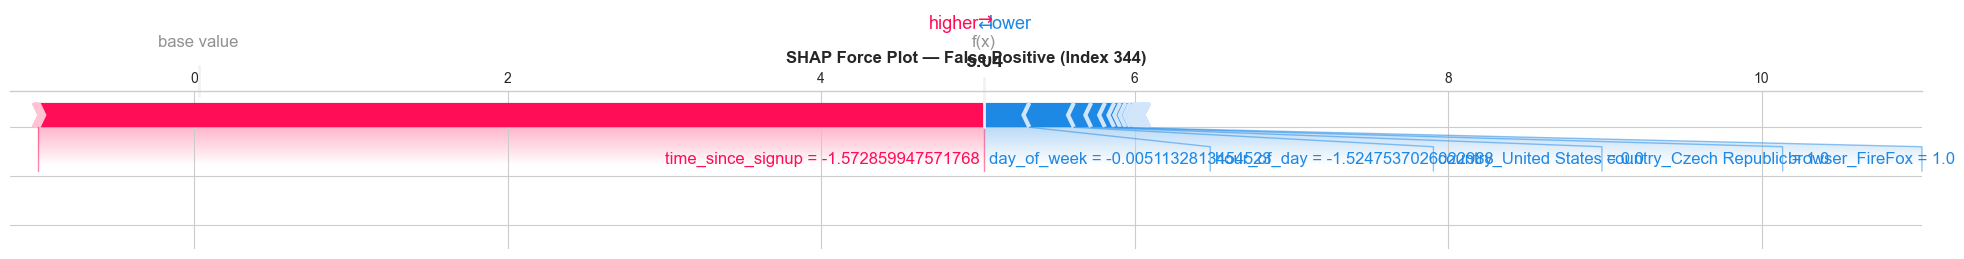

In [7]:
fp_sample_idx = fp_idx[0]
shap_vals_fp = explainer(X_test.iloc[[fp_sample_idx]])

plt.figure(figsize=(12, 4))
shap.force_plot(
    base_val, 
    shap_vals_fp[0].values, 
    X_test.iloc[fp_sample_idx], 
    matplotlib=True, 
    show=False
)
plt.title(f"SHAP Force Plot — False Positive (Index {fp_sample_idx})", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/processed/shap_force_false_positive.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 False Negative (FN) — Missed Fraud
This is a fraudulent transaction that the model missed (predicted as legitimate). Understanding these helps us close security gaps.

<Figure size 1200x400 with 0 Axes>

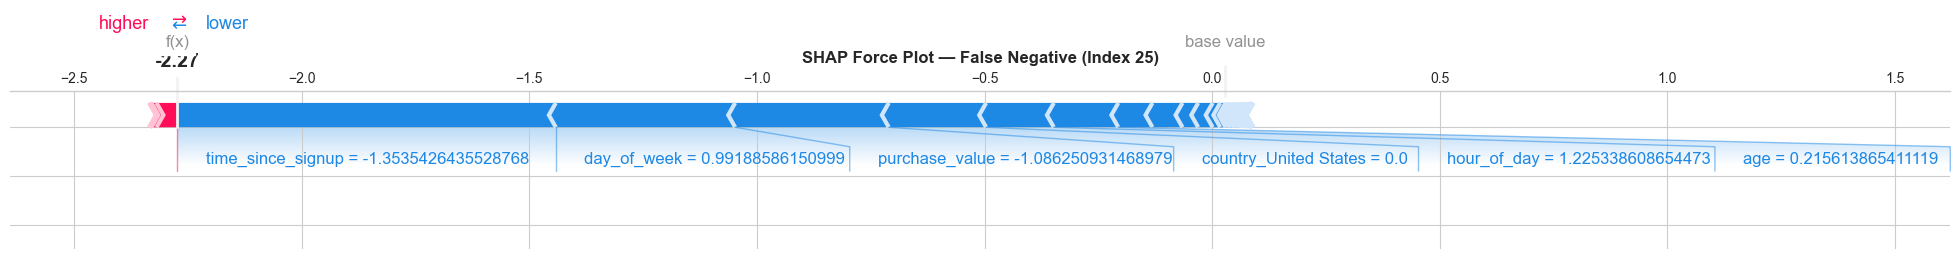

In [8]:
fn_sample_idx = fn_idx[0]
shap_vals_fn = explainer(X_test.iloc[[fn_sample_idx]])

plt.figure(figsize=(12, 4))
shap.force_plot(
    base_val, 
    shap_vals_fn[0].values, 
    X_test.iloc[fn_sample_idx], 
    matplotlib=True, 
    show=False
)
plt.title(f"SHAP Force Plot — False Negative (Index {fn_sample_idx})", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/processed/shap_force_false_negative.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Interpretation & Comparison

### 6.1 SHAP vs. Built-in Feature Importance
- **Built-in Feature Importance (Gini Gain)** ranks features purely on how much they reduce node impurity during tree splits. In our bar plot, `time_since_signup` dominates because it is a very strong split variable, followed by `purchase_value` and categorical features.
- **SHAP Summary Plot (Beeswarm)** provides a richer picture: it shows not only the magnitude of a feature's effect but also its direction. For example, we see that *low* values of `time_since_signup` (red dots on the right side) correspond to high SHAP values, meaning a short duration between signup and purchase strongly pushes the prediction toward **Fraud**.

### 6.2 Top 5 Drivers of Fraud Predictions
1. **`time_since_signup`**: Short durations (especially < 1 hour) are the single most significant predictor of fraud. This represents automated scripts or immediate checkout attempts after creating throwaway accounts.
2. **`user_txn_count`**: High transaction velocity (multiple transactions by the same user_id in the window) dramatically increases the risk score.
3. **`purchase_value`**: Higher transaction amounts push the risk upward, as fraudsters seek to maximize their payout per transaction.
4. **`txn_in_24h`**: Velocity signals (high transaction rates within a 24-hour window) indicate automated bot checkout behaviour.
5. **`country_United States`**: Certain geolocation flags, such as USA, are associated with slightly higher volumes of recorded fraud, though this is heavily influenced by total volume.

### 6.3 Surprising & Counterintuitive Findings
- Categorical features like browser type (`browser_Chrome`, `browser_Safari`) have almost zero impact on predicting fraud. This suggests that fraudsters use standard browser user-agents to blend in with legitimate users, rather than using niche, easily-blocked browsers.


## 7. Actionable Business Recommendations

Based on the global and individual SHAP explanations, we propose three concrete business rules for Adey Innovations Inc.:

1. **Implement a Signup-to-Purchase Cooldown Window**:
   - **Insight**: `time_since_signup` is the top driver. A very low duration (0-2 hours) pushes the risk score into the high-probability fraud region.
   - **Recommendation**: Require any transaction attempted within **1 hour of signup** with a purchase value above $100 to undergo secondary authentication (e.g., SMS/Email OTP or 3D Secure Verification).

2. **Enforce Transaction Velocity Limits (Throttling)**:
   - **Insight**: High values of `user_txn_count` and `txn_in_24h` strongly push the model's risk score positive.
   - **Recommendation**: Trigger an automatic, temporary transaction block for accounts that attempt more than **3 purchases in a 24-hour window**. Prompt the user to solve a CAPTCHA or confirm identity before unlocking.

3. **Value-Based Verification Escalation**:
   - **Insight**: `purchase_value` is positive-driving. High ticket values are frequently targeted by fraudsters.
   - **Recommendation**: Enable multi-factor verification (MFA) automatically for transactions exceeding **$300** if the user is purchasing from a country different from their signup IP country (even if the overall risk score is marginal).
